<a href="https://colab.research.google.com/github/ja2faded/A01-data-wrangling/blob/main/A2_DATAVISUALIZATIONnotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Jackson Gayeski

**Date:** 9/10/26

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


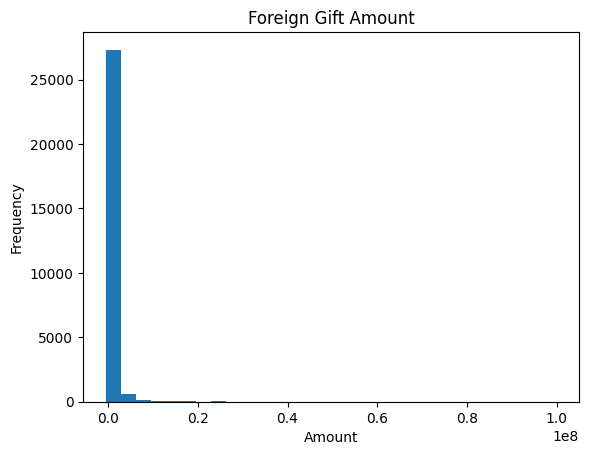

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


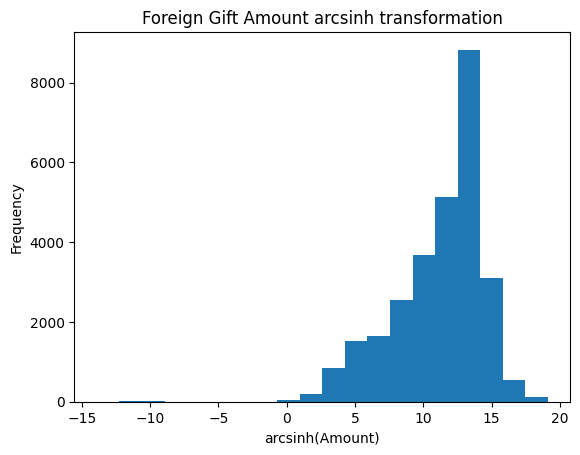

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


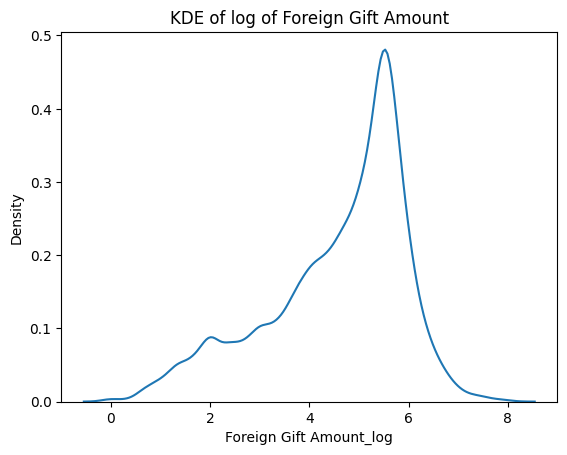

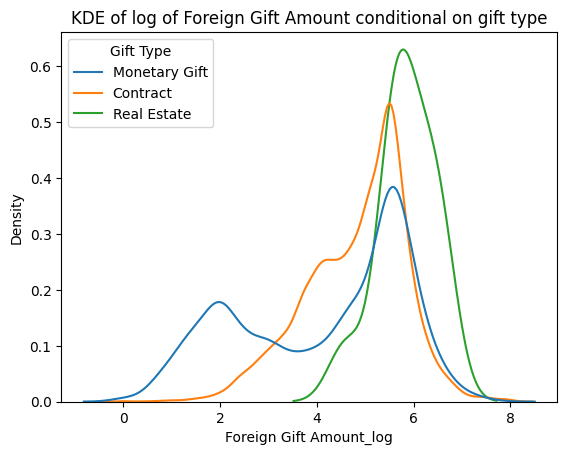

top 15 countries in terms of the number of gifts Index(['ENGLAND', 'CHINA', 'CANADA', 'JAPAN', 'SWITZERLAND', 'SAUDI ARABIA',
       'FRANCE', 'GERMANY', 'HONG KONG', 'SOUTH KOREA', 'QATAR',
       'THE NETHERLANDS', 'KOREA', 'INDIA', 'TAIWAN'],
      dtype='object', name='Country of Giftor')
top 15 countries in terms of the amount given Index(['QATAR', 'ENGLAND', 'CHINA', 'SAUDI ARABIA', 'BERMUDA', 'CANADA',
       'HONG KONG', 'JAPAN', 'SWITZERLAND', 'INDIA', 'GERMANY',
       'UNITED ARAB EMIRATES', 'FRANCE', 'SINGAPORE', 'AUSTRALIA'],
      dtype='object', name='Country of Giftor')
top giftors:  Index(['Qatar Foundation', 'Qatar Foundation/Qatar National Res',
       'Qatar Foundation for Education', 'Anonymous',
       'Saudi Arabian Cultural Mission', 'HCL',
       'Church of Jesus Christ of LDS', 'Emirates Institute for Advanced Sc',
       'QIC', 'Anonymous #9', 'Qatar National Research Fund',
       'Government of Saudi Arabia', 'Contracting Party', 'CMKL University',
       '

In [36]:
from google.colab import drive
drive.mount ('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#1
#load data set
df = pd.read_csv('/content/drive/MyDrive/ForeignGifts_edu.csv')

#2 hist of Foreign Gift Amount
df['Foreign Gift Amount'].hist(bins=30, grid=False)
plt.title("Foreign Gift Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()
#histogram has spike near 0; not much of a bell shape;appears very right skewed

#2
#describe Foreign Gift Amount
print(df['Foreign Gift Amount'].describe())
# The mean = 5.882327e+05 and the median = 9.461500e+04; this gap confirms a large right skew
# The sd = 3.222011e+06 and the range is from -5.377700e+05 to 1.000000e+08
# indicating the data is very spread out


#arcsin histogram
df["Foreign Gift Amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["Foreign Gift Amount_arcsinh"].hist(bins=20, grid=False)
plt.title("Foreign Gift Amount arcsinh transformation")
plt.xlabel("arcsinh(Amount)")
plt.ylabel("Frequency")
plt.show()
#arcsin stops right skew


#3
#Gift Type raw count
print(df['Gift Type'].value_counts())

#Gift Type value counts; normalize = True outputs them as proportions
print(df["Gift Type"].value_counts(normalize = True))
# Contract = 0.612097, Monetary Gift = 0.387513, Real Estate = 0.000390

#4

#kernel density plot of the log of Foreign Gift Amount
#log10 makes - numbers undefined, so they are dropped from the kde plot
df['Foreign Gift Amount_log'] = np.log10(df['Foreign Gift Amount'])
sns.kdeplot(data = df, x = 'Foreign Gift Amount_log')
plt.title("KDE of log of Foreign Gift Amount")
plt.show()

#kernel density plot of the log of Foreign Gift Amount conditional on gift type
#print(sns.kdeplot(data = df, x = 'Foreign Gift Amount_log', hue = 'Gift Type'))
##based on the plot: Real estate takes up a very small portion of the gift types (confirmed above)

#common_norm = False makes it so sample size does not affect the height of each line
sns.kdeplot(data = df, x = 'Foreign Gift Amount_log', hue = 'Gift Type', common_norm=False)
plt.title("KDE of log of Foreign Gift Amount conditional on gift type")
plt.show()
#based on the plot, gift type influences amount. Real estate gifts are typically the largest, followed by Contracts
#monetary gifts tend to be the smallest.


#5
#count rows per country; sort descending; top 15
top_15_number_of_gifts = df['Country of Giftor'].value_counts().head(15).index
print('top 15 countries in terms of the number of gifts', top_15_number_of_gifts)

#sum of total gift amount per country; sorted descending; top 15
top_15_amount_given = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(15).index
print('top 15 countries in terms of the amount given', top_15_amount_given)

#6
#sum of total gift amount per giftor name; sorted descending; top 15
#excluded rows with no giftor name reported
top_giftors = df.dropna(subset=['Giftor Name']).groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(15).index
print('top giftors: ', top_giftors)
#several of the top 15 have non-identifiable names ("Amonymous" fe)












## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [35]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]